# Notebook 2 — Transmon Spectrum and Anharmonicity

Compare three calculations of the transmon spectrum:

1. **Exact**: numerical diagonalization of the full CPB Hamiltonian $H = 4 E_C (\hat n - n_g)^2 - E_J \cos\hat\delta$.
2. **Duffing**: harmonic oscillator with quartic anharmonic correction, $H = \hbar \omega_q b^\dagger b + \tfrac{\alpha}{2} b^\dagger b^\dagger b b$, with $\omega_q = \sqrt{8 E_J E_C}/\hbar - E_C/\hbar$ and $\alpha = -E_C/\hbar$.
3. **Perturbative formula**: $E_n = \sqrt{8 E_J E_C}\,(n + \tfrac{1}{2}) - \tfrac{E_C}{12}(6 n^2 + 6 n + 3)$.

We track:

- the qubit transition $\omega_{01} = E_1 - E_0$, and
- the anharmonicity $\alpha_{\text{eff}} = \omega_{12} - \omega_{01}$,

as functions of $E_J/E_C \in [10, 100]$. The plot shows where the perturbative approximations break down, and confirms why $E_J/E_C \gtrsim 50$ is the standard transmon operating regime.

All energies are reported in units of $E_C$ (i.e. $E_C = 1$, $\hbar = 1$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


def cpb_hamiltonian(EJ_over_EC, ng=0.0, N=30):
    """CPB Hamiltonian in the charge basis. E_C = 1."""
    n = np.arange(-N, N + 1)
    diag = 4.0 * (n - ng) ** 2
    off = -0.5 * EJ_over_EC
    H = np.diag(diag) + np.diag(np.full(2 * N, off), k=1) \
                       + np.diag(np.full(2 * N, off), k=-1)
    return H


def transmon_levels_exact(EJ_over_EC, n_levels=3, N=40):
    """Exact lowest n_levels eigenvalues of the transmon at ng=0."""
    H = cpb_hamiltonian(EJ_over_EC, ng=0.0, N=N)
    evals = np.linalg.eigvalsh(H)
    return evals[:n_levels]


# Quick check at EJ/EC = 50
e0, e1, e2 = transmon_levels_exact(50.0, n_levels=3)
print(f"EJ/EC = 50:")
print(f"  E0/E_C = {e0:.4f}")
print(f"  E1/E_C = {e1:.4f}")
print(f"  E2/E_C = {e2:.4f}")
print(f"  omega_01/E_C = {e1 - e0:.4f}")
print(f"  anharmonicity (omega_12 - omega_01)/E_C = {(e2 - e1) - (e1 - e0):.4f}")
print(f"  (Should be close to -1, since alpha ≈ -E_C for the transmon)")

EJ/EC = 50:
  E0/E_C = -40.2568
  E1/E_C = -21.3149
  E2/E_C = -3.5222
  omega_01/E_C = 18.9419
  anharmonicity (omega_12 - omega_01)/E_C = -1.1492
  (Should be close to -1, since alpha ≈ -E_C for the transmon)


In [2]:
def transmon_levels_duffing(EJ_over_EC, n_levels=3, N_fock=20):
    """
    Duffing-oscillator approximation of the transmon spectrum.

    H/E_C = omega_q (b^dag b)  +  (alpha/2) b^dag b^dag b b,
    with omega_q/E_C = sqrt(8 EJ/EC) - 1 and alpha/E_C = -1.

    Diagonalised exactly in a truncated Fock basis.
    """
    omega_q = np.sqrt(8 * EJ_over_EC) - 1.0
    alpha = -1.0
    n = np.arange(N_fock)
    diag = omega_q * n + 0.5 * alpha * n * (n - 1)
    return np.sort(diag)[:n_levels]


def transmon_levels_perturbative(EJ_over_EC, n_levels=3):
    """
    Koch et al. 2007 perturbative formula:
      E_n / E_C = sqrt(8 EJ/EC) (n + 1/2) - (1/12) (6 n^2 + 6 n + 3).
    """
    levels = []
    for n in range(n_levels):
        E_n = np.sqrt(8 * EJ_over_EC) * (n + 0.5) - (6 * n ** 2 + 6 * n + 3) / 12.0
        levels.append(E_n)
    return np.array(levels)


# Sweep EJ/EC and compute omega_01 and anharmonicity by all three methods
ratio_grid = np.linspace(10, 100, 60)

omega01 = {"exact": [], "duffing": [], "perturb": []}
anharm  = {"exact": [], "duffing": [], "perturb": []}

for ratio in ratio_grid:
    e_exact   = transmon_levels_exact(ratio, n_levels=3)
    e_duff    = transmon_levels_duffing(ratio, n_levels=3)
    e_pert    = transmon_levels_perturbative(ratio, n_levels=3)

    for label, e in [("exact", e_exact), ("duffing", e_duff), ("perturb", e_pert)]:
        omega01[label].append(e[1] - e[0])
        anharm [label].append((e[2] - e[1]) - (e[1] - e[0]))

for label in omega01:
    omega01[label] = np.array(omega01[label])
    anharm [label] = np.array(anharm[label])

print(f"Computed three methods at {len(ratio_grid)} points.")
print(f"At EJ/EC = 50:")
print(f"  omega_01: exact = {omega01['exact'][np.argmin(np.abs(ratio_grid - 50))]:.4f}, "
      f"duffing = {omega01['duffing'][np.argmin(np.abs(ratio_grid - 50))]:.4f}, "
      f"perturb = {omega01['perturb'][np.argmin(np.abs(ratio_grid - 50))]:.4f}")
print(f"  anharmonicity: exact = {anharm['exact'][np.argmin(np.abs(ratio_grid - 50))]:.4f}, "
      f"duffing = {anharm['duffing'][np.argmin(np.abs(ratio_grid - 50))]:.4f}, "
      f"perturb = {anharm['perturb'][np.argmin(np.abs(ratio_grid - 50))]:.4f}")

Computed three methods at 60 points.
At EJ/EC = 50:
  omega_01: exact = 18.8738, duffing = 18.9321, perturb = 18.9321
  anharmonicity: exact = -1.1499, duffing = -1.0000, perturb = -1.0000


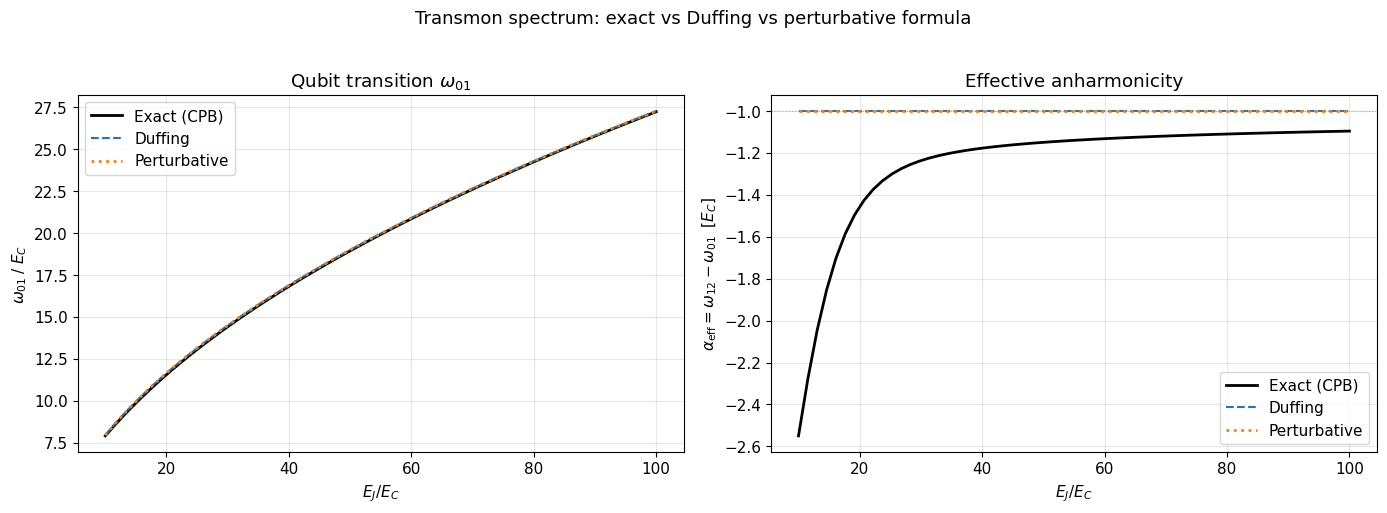

Figure saved to figures/02_transmon_spectrum.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left panel: omega_01 ----
ax = axes[0]
ax.plot(ratio_grid, omega01["exact"],   "k-",  lw=2.0, label="Exact (CPB)")
ax.plot(ratio_grid, omega01["duffing"], "C0--", lw=1.5, label="Duffing")
ax.plot(ratio_grid, omega01["perturb"], "C1:",  lw=2.0, label="Perturbative")
ax.set_xlabel(r"$E_J / E_C$")
ax.set_ylabel(r"$\omega_{01} \;/\; E_C$")
ax.set_title(r"Qubit transition $\omega_{01}$")
ax.legend()

# ---- Right panel: anharmonicity ----
ax = axes[1]
ax.plot(ratio_grid, anharm["exact"],   "k-",  lw=2.0, label="Exact (CPB)")
ax.plot(ratio_grid, anharm["duffing"], "C0--", lw=1.5, label="Duffing")
ax.plot(ratio_grid, anharm["perturb"], "C1:",  lw=2.0, label="Perturbative")
ax.set_xlabel(r"$E_J / E_C$")
ax.set_ylabel(r"$\alpha_{\mathrm{eff}} = \omega_{12} - \omega_{01} \;\;[E_C]$")
ax.set_title(r"Effective anharmonicity")
ax.axhline(-1.0, color="grey", lw=0.8, ls=":", alpha=0.6)
ax.legend()

fig.suptitle(
    r"Transmon spectrum: exact vs Duffing vs perturbative formula",
    y=1.02, fontsize=13,
)
fig.tight_layout()

import os
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/02_transmon_spectrum.png", dpi=200, bbox_inches="tight")

plt.show()
print("Figure saved to figures/02_transmon_spectrum.png")

In [4]:
def transmon_levels_duffing(EJ_over_EC, n_levels=3):
    """
    Duffing-oscillator spectrum: take the first n_levels Fock states directly,
    *without* sorting. The Duffing model is meant to describe the lowest few
    levels of a slightly anharmonic oscillator; sorting all Fock energies and
    picking the smallest is incorrect when the negative quartic causes
    high-n Fock energies to dip below low-n ones (a model artifact, not physics).
    """
    omega_q = np.sqrt(8 * EJ_over_EC) - 1.0
    alpha = -1.0
    n = np.arange(n_levels)
    return omega_q * n + 0.5 * alpha * n * (n - 1)


# Re-run the sweep with the corrected Duffing function
omega01 = {"exact": [], "duffing": [], "perturb": []}
anharm  = {"exact": [], "duffing": [], "perturb": []}

for ratio in ratio_grid:
    e_exact = transmon_levels_exact(ratio, n_levels=3)
    e_duff  = transmon_levels_duffing(ratio, n_levels=3)
    e_pert  = transmon_levels_perturbative(ratio, n_levels=3)

    for label, e in [("exact", e_exact), ("duffing", e_duff), ("perturb", e_pert)]:
        omega01[label].append(e[1] - e[0])
        anharm [label].append((e[2] - e[1]) - (e[1] - e[0]))

for label in omega01:
    omega01[label] = np.array(omega01[label])
    anharm [label] = np.array(anharm[label])

print("Re-computed with fixed Duffing.")

Re-computed with fixed Duffing.
